## Drzewa decyzyjne i lasy losowe


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
data = load_iris()
X = data.data
y = data.target
print(data.DESCR ,data.feature_names)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

tree_model = DecisionTreeClassifier(max_depth=3 ,random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)
accuracy_tree = accuracy_score(y_test, y_pred_tree)
print("Dokładność modelu drzewa decyzyjnego:", accuracy_tree)
print("Raport klasyfikacji:\n", classification_report(y_test, y_pred_tree))
print("Macierz konfuzji:\n", confusion_matrix(y_test, y_pred_tree))

Dokładność modelu drzewa decyzyjnego: 1.0
Raport klasyfikacji:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Macierz konfuzji:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [5]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Dokładność modelu Random Forest:", accuracy_rf)
print("Raport klasyfikacji:\n", classification_report(y_test, y_pred_rf))
print("Macierz konfuzji:\n", confusion_matrix(y_test, y_pred_rf))

Dokładność modelu Random Forest: 1.0
Raport klasyfikacji:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Macierz konfuzji:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [6]:
feature_importances = rf_model.feature_importances_
for i, feature in enumerate(data.feature_names):
    print(f"Ważność cechy'{feature}': {feature_importances[i]:.4f}")

Ważność cechy'sepal length (cm)': 0.1081
Ważność cechy'sepal width (cm)': 0.0304
Ważność cechy'petal length (cm)': 0.4400
Ważność cechy'petal width (cm)': 0.4215


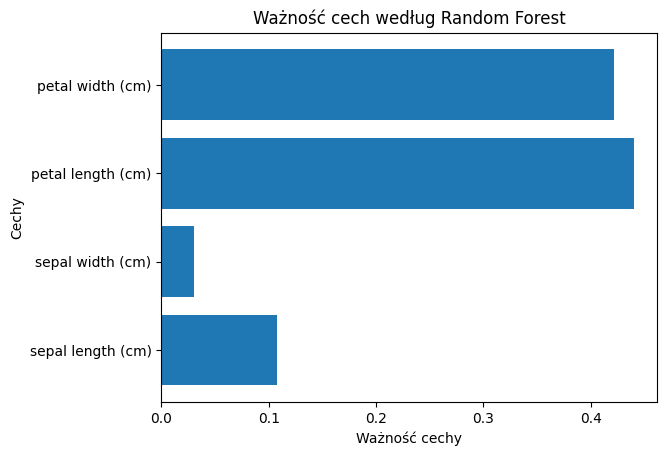

In [7]:
plt.barh(data.feature_names, feature_importances)
plt.xlabel("Ważność cechy")
plt.ylabel("Cechy")
plt.title("Ważność cech według Random Forest")
plt.show()

In [ ]:
df = pd.read_csv("student_performance.csv")
df.drop(columns=["parent_education"], inplace=True)
print(df.head())
print(df.info())

  student_id  gender  age  study_hours_per_week  attendance_rate  \
0    STU0001    Male   15                    25             63.8   
1    STU0002  Female   15                     2             54.7   
2    STU0003  Female   19                    10             90.5   
3    STU0004    Male   16                    26             66.8   
4    STU0005  Female   15                    25             73.0   

  parent_education internet_access extracurricular  previous_score  \
0         Bachelor             Yes             Yes              41   
1         Bachelor             Yes             Yes              83   
2      High School             Yes              No              73   
3      High School              No             Yes              75   
4      High School              No             Yes              67   

   final_score passed  
0           67    Yes  
1           28     No  
2           49     No  
3           70    Yes  
4           77    Yes  
<class 'pandas.core.frame.

In [19]:
X_adult = df.drop("income", axis=1)
y_adult = df["income"]
X_train_adult, X_test_adult, y_train_adult, y_test_adult = train_test_split(X_adult, y_adult, test_size=0.2, random_state=17)
for depth in range(1, 6):
    tree_model_adult = DecisionTreeClassifier(max_depth=depth, random_state=17)
    tree_model_adult.fit(X_train_adult, y_train_adult)
    y_pred_tree_adult = tree_model_adult.predict(X_test_adult)
    accuracy_tree_adult = accuracy_score(y_test_adult, y_pred_tree_adult)
    print(f"Dokładność modelu drzewa decyzyjnego (max_depth={depth}): {accuracy_tree_adult:.4f}")

ValueError: could not convert string to float: 'Private'